# 01 — Análisis exploratorio de la calidad del aire de Madrid (2018–2026)

**Objetivo**: entender la estructura del dataset histórico del Ayuntamiento de Madrid antes de
diseñar el detector de anomalías.

El dataset viene en **formato ancho**: una fila por (estación, magnitud, día) con 24 columnas de
valor `H01..H24` y 24 flags de validación `V01..V24` (`V` = válido, `N` = no válido / no medido).

Preguntas que responde este notebook:
1. ¿Qué volumen y cobertura temporal tiene cada contaminante y estación?
2. ¿Qué significa realmente el flag de validación `V`? ¿Podemos ignorarlo?
3. ¿Qué patrones diarios y estacionales existen? (serán la base del modelo de *expected value*)

In [1]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd

# Estilo: marcas finas, ejes y rejilla recesivos
mpl.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e0e0e0", "grid.linewidth": 0.6,
    "axes.axisbelow": True, "lines.linewidth": 2,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "figure.dpi": 110,
})

# Paleta categórica fija por contaminante (Okabe-Ito, segura para daltonismo).
# El color sigue a la entidad: cada contaminante tiene SIEMPRE el mismo color.
PALETA = {
    "NO2":   "#0072B2",
    "NO":    "#56B4E9",
    "NOx":   "#CC79A7",
    "O3":    "#009E73",
    "PM10":  "#E69F00",
    "PM2.5": "#D55E00",
}
MAGNITUDES = {7: "NO", 8: "NO2", 9: "PM2.5", 10: "PM10", 12: "NOx", 14: "O3"}
ORDEN = ["NO2", "NO", "NOx", "O3", "PM10", "PM2.5"]

In [2]:
RUTA_CSV = "../data/raw/datos_completos_2018_2026.csv"
df = pd.read_csv(RUTA_CSV, sep=";")
print(f"Filas (estación-magnitud-día): {len(df):,}")
print(f"Estaciones: {df.ESTACION.nunique()} | Magnitudes: {sorted(df.MAGNITUD.unique())}")
print(f"Rango temporal: {df.ANO.min()}–{df.ANO.max()}")
df.head(3)

Filas (estación-magnitud-día): 417,629
Estaciones: 24 | Magnitudes: [np.int64(1), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(12), np.int64(14), np.int64(20), np.int64(30), np.int64(35), np.int64(42), np.int64(43), np.int64(44)]
Rango temporal: 2018–2026


,PROVINCIA,MUNICIPIO,ESTACION,MAGNITUD,PUNTO_MUESTREO,ANO,MES,DIA,H01,V01,...,H20,V20,H21,V21,H22,V22,H23,V23,H24,V24
0,28,79,4,1,28079004_1_38,2018,1,1,1.0,V,...,2.0,V,1.0,V,1.0,V,1.0,V,1.0,V
1,28,79,4,6,28079004_6_48,2018,1,1,0.3,V,...,0.3,V,0.3,V,0.3,V,0.3,V,0.3,V
2,28,79,4,7,28079004_7_8,2018,1,1,2.0,V,...,4.0,V,3.0,V,2.0,V,2.0,V,1.0,V


## 1. Volumen por magnitud

No todas las estaciones miden todos los contaminantes. Nos quedaremos con las 6 magnitudes
objetivo del proyecto: **NO (7), NO2 (8), PM2.5 (9), PM10 (10), NOx (12) y O3 (14)**.

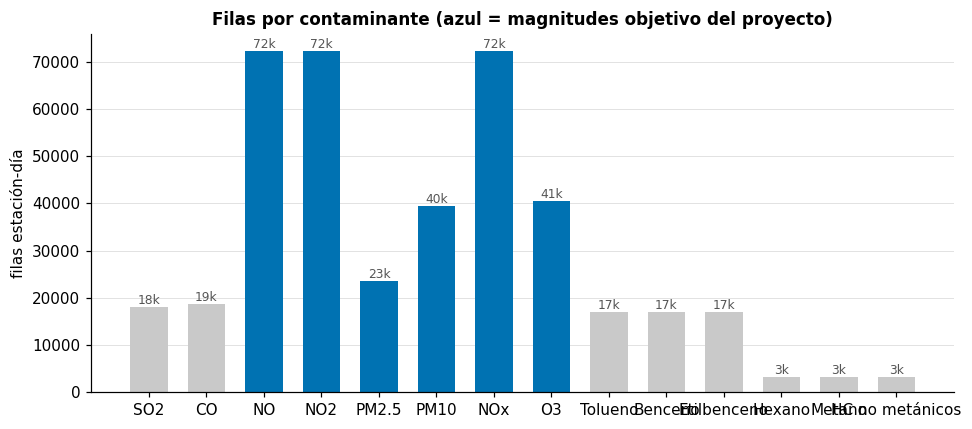

Dataset filtrado a magnitudes objetivo: 320,129 filas


In [3]:
vol = df.MAGNITUD.value_counts().sort_index()
etiquetas_mag = {1: "SO2", 6: "CO", 7: "NO", 8: "NO2", 9: "PM2.5", 10: "PM10", 12: "NOx",
                 14: "O3", 20: "Tolueno", 30: "Benceno", 35: "Etilbenceno",
                 42: "Hexano", 43: "Metano", 44: "HC no metánicos"}

fig, ax = plt.subplots(figsize=(9, 4))
nombres = [etiquetas_mag.get(m, str(m)) for m in vol.index]
colores = ["#0072B2" if m in MAGNITUDES else "#c9c9c9" for m in vol.index]
bars = ax.bar(nombres, vol.values, color=colores, width=0.65)
for b, v in zip(bars, vol.values):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v/1000:.0f}k", ha="center", va="bottom", fontsize=8, color="#555")
ax.set_title("Filas por contaminante (azul = magnitudes objetivo del proyecto)")
ax.set_ylabel("filas estación-día")
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

df = df[df.MAGNITUD.isin(MAGNITUDES)].copy()
df["CONTAMINANTE"] = df.MAGNITUD.map(MAGNITUDES)
print(f"Dataset filtrado a magnitudes objetivo: {len(df):,} filas")

## 2. El flag de validación: los valores con `V=N` son ceros falsos

Antes de decidir si usamos o ignoramos el flag, veamos qué valores acompañan a cada flag.
Si `N` marcase "mediciones sospechosas" tendría valores variados; si marca "hora no medida",
los valores serán placeholders.

In [4]:
# Apilamos una muestra de pares (valor, flag) de las 24 horas
muestra = df.sample(min(40_000, len(df)), random_state=0)
pares = []
for h in range(1, 25):
    pares.append(pd.DataFrame({"VALOR": muestra[f"H{h:02d}"], "FLAG": muestra[f"V{h:02d}"].str.strip()}))
pares = pd.concat(pares, ignore_index=True)

resumen_flags = pares.groupby("FLAG")["VALOR"].agg(
    n="count", pct_ceros=lambda s: (s == 0).mean(), media="mean", maximo="max")
resumen_flags["pct_ceros"] = (resumen_flags["pct_ceros"] * 100).round(1)
print(resumen_flags.round(2))

           n  pct_ceros   media   maximo
FLAG                                    
M          3        0.0  148.00    231.0
N      13308       44.5   40.88  69846.0
V     946689        1.0   29.04   1422.0


**Conclusión clave**: las horas con flag `N` son una mezcla de **ceros placeholder** (~45%,
horas no medidas) y **lecturas corruptas** (valores extremos de decenas de miles de µg/m³,
físicamente imposibles). En ningún caso son mediciones fiables. Por tanto:

- Entrenar "con todo" incluyendo las `N` inyectaría ceros falsos y valores corruptos en el modelo.
- El flag **no se usa como etiqueta de anomalía** pero **sí como máscara de datos ausentes**.

## 3. Cobertura por estación y contaminante

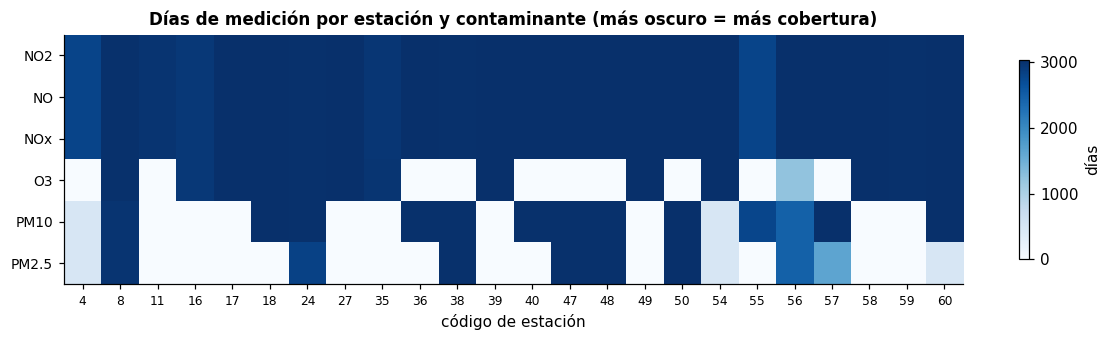

Estaciones que miden partículas PM2.5: 11 de 24


In [5]:
cobertura = df.groupby(["CONTAMINANTE", "ESTACION"]).size().unstack(fill_value=0)
cobertura = cobertura.reindex(ORDEN)

fig, ax = plt.subplots(figsize=(11, 3.2))
im = ax.imshow(cobertura.values, aspect="auto", cmap="Blues")
ax.set_xticks(range(len(cobertura.columns)), cobertura.columns, fontsize=8)
ax.set_yticks(range(len(cobertura.index)), cobertura.index, fontsize=9)
ax.set_title("Días de medición por estación y contaminante (más oscuro = más cobertura)")
ax.set_xlabel("código de estación")
ax.grid(visible=False)
fig.colorbar(im, ax=ax, shrink=0.8, label="días")
plt.tight_layout(); plt.show()

print("Estaciones que miden partículas PM2.5:", (cobertura.loc["PM2.5"] > 0).sum(), "de", cobertura.shape[1])

Se confirma que **NO/NO2/NOx se miden en las 24 estaciones**, mientras que las
partículas y el ozono solo en un subconjunto. El detector debe entrenarse por magnitud y
ser robusto a que cada estación tenga su propio nivel base (una estación de tráfico no es
comparable a una de fondo urbano).

## 4. Patrones temporales

Pasamos a formato largo con `wide_a_largo`, el parser **compartido** del proyecto
(`src/etl/limpiar_datos.py`) — el mismo que usa la ingesta en tiempo real — y estudiamos los
ciclos diarios y estacionales.

In [6]:
# Reutilizamos el ÚNICO parser de despivotado del proyecto, definido en
# src/etl/limpiar_datos.py. Es exactamente el mismo que usa la ingesta en tiempo
# real, así que el histórico y el endpoint se transforman de forma idéntica.
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join("..", "src", "etl")))
from limpiar_datos import wide_a_largo

MAGNITUDES_OBJETIVO = [7, 8, 9, 10, 12, 14]  # NO, NO2, PM2.5, PM10, NOx, O3

In [7]:
largo = wide_a_largo(df, MAGNITUDES_OBJETIVO)
largo["CONTAMINANTE"] = largo.MAGNITUD.map(MAGNITUDES)
print(f"{len(largo):,} mediciones horarias válidas")
largo.head(3)

7,574,463 mediciones horarias válidas


,ESTACION,MAGNITUD,FECHA,HORA,VALOR,VALIDO,CONTAMINANTE
0,4,7,2018-01-01,0,2.0,True,NO
1,4,7,2018-01-01,1,1.0,True,NO
2,4,7,2018-01-01,2,1.0,True,NO


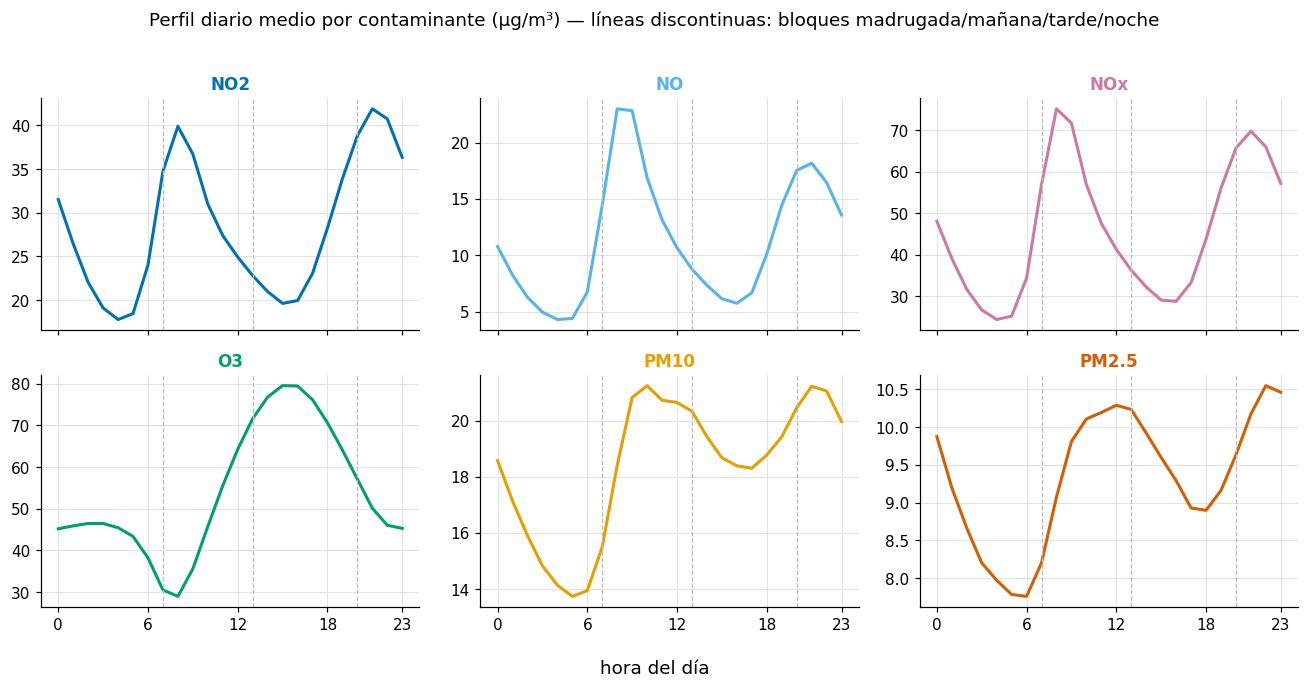

In [8]:
perfil_hora = largo.groupby(["CONTAMINANTE", "HORA"])["VALOR"].mean().unstack(level=0)

fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True)
for ax, cont in zip(axes.flat, ORDEN):
    serie = perfil_hora[cont]
    ax.plot(serie.index, serie.values, color=PALETA[cont])
    ax.set_title(cont, color=PALETA[cont])
    ax.set_xticks([0, 6, 12, 18, 23])
    # Bloques del día usados por ResumenDatosML
    for x in (7, 13, 20):
        ax.axvline(x, color="#bbbbbb", linewidth=0.8, linestyle="--")
fig.suptitle("Perfil diario medio por contaminante (µg/m³) — líneas discontinuas: bloques madrugada/mañana/tarde/noche", y=1.02)
fig.supxlabel("hora del día"); plt.tight_layout(); plt.show()

Los perfiles diarios validan la **agregación por bloques** (madrugada 0-6, mañana 7-12,
tarde 13-19, noche 20-23): los óxidos de nitrógeno tienen dos picos (horas punta de tráfico)
que caen en bloques distintos, y el O3 tiene su máximo en el bloque de tarde (fotoquímico).
Un bloque captura un "régimen" del día sin diluir los picos como haría una media diaria.

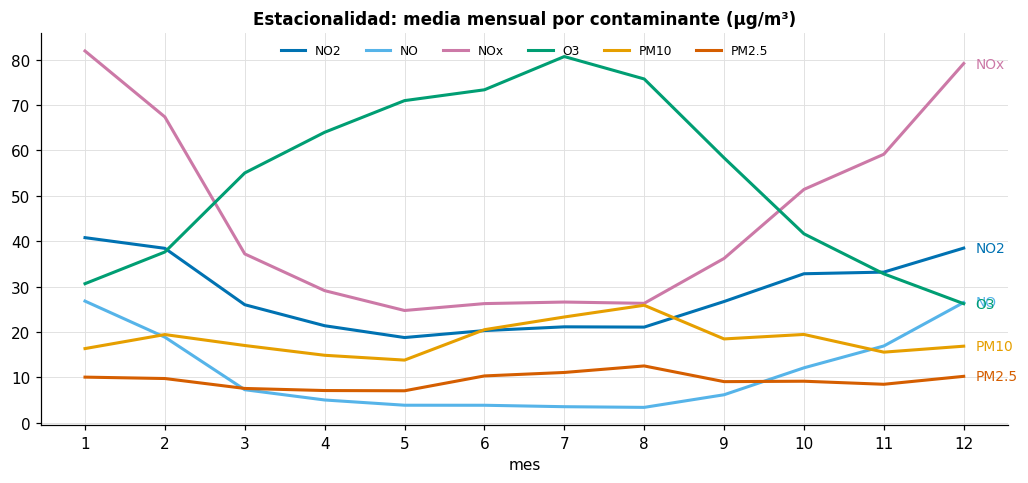

In [9]:
largo["MES"] = pd.to_datetime(largo.FECHA.astype(str)).dt.month
perfil_mes = largo.groupby(["CONTAMINANTE", "MES"])["VALOR"].mean().unstack(level=0)

fig, ax = plt.subplots(figsize=(9.5, 4.5))
for cont in ORDEN:
    ax.plot(perfil_mes.index, perfil_mes[cont], color=PALETA[cont], label=cont)
    ax.text(12.15, perfil_mes[cont].iloc[-1], cont, color=PALETA[cont], fontsize=9, va="center")
ax.set_xticks(range(1, 13))
ax.set_title("Estacionalidad: media mensual por contaminante (µg/m³)")
ax.set_xlabel("mes"); ax.legend(loc="upper center", ncols=6, frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

La estacionalidad es fuerte y **opuesta entre O3 (máximo en verano) y NOx (máximo en
invierno)**. Conclusión para el modelo: el *valor esperado* debe condicionarse como mínimo a
(estación, magnitud, bloque del día, mes) — exactamente la jerarquía del `BaselineHistorico`.

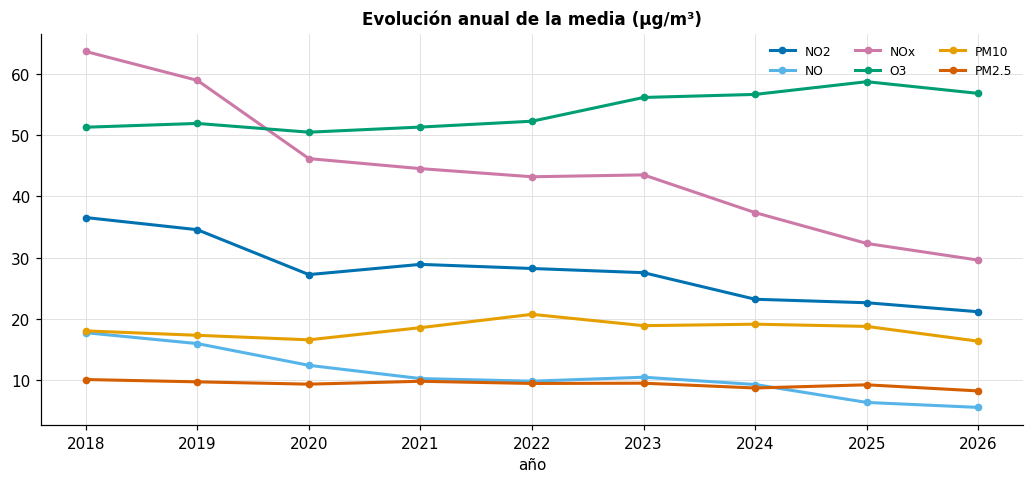

In [10]:
anual = largo.groupby(["CONTAMINANTE", pd.to_datetime(largo.FECHA.astype(str)).dt.year])["VALOR"].mean().unstack(level=0)

fig, ax = plt.subplots(figsize=(9.5, 4.5))
for cont in ORDEN:
    ax.plot(anual.index, anual[cont], color=PALETA[cont], label=cont, marker="o", markersize=4)
ax.set_title("Evolución anual de la media (µg/m³)")
ax.set_xlabel("año"); ax.legend(loc="upper right", ncols=3, frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

## Conclusiones del EDA

1. **Formato**: ancho → largo con `H01→hora 0 ... H24→hora 23`; mismo parser sirve para el
   histórico y para el endpoint en tiempo real.
2. **Flag V**: las horas `N` son ceros placeholder → se tratan como *missing*, nunca como datos.
   El flag no se usa como etiqueta de anomalía.
3. **Cobertura heterogénea**: modelos por magnitud; el nivel base depende de la estación.
4. **Ciclos fuertes** diario y estacional → el baseline debe condicionar por
   (estación, magnitud, bloque, mes); los bloques del día capturan bien los regímenes.
